In [1]:
!pip install gdown
!pip install -q transformers torch sentencepiece huggingface_hub

In [2]:
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.6 MB/s eta 0:00:00


In [ ]:
import os
import re
import math
import random
import string
import warnings

import gdown
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization,
    SimpleRNN,
    LSTM,
    Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from underthesea import text_normalize
from tqdm import tqdm

warnings.filterwarnings('ignore')

2026-05-24 20:55:30.035145: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779656130.250661      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779656130.314859      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779656130.815296      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779656130.815334      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779656130.815337      23 computation_placer.cc:177] computation placer alr

In [4]:
# Cài đặt wrapper Python cho VnCoreNLP.
!pip install vncorenlp

# Tải xuống VnCoreNLP và thành phần phân đoạn từ (RDRSegmenter).
!mkdir -p vncorenlp/models/wordsegmenter
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/vi-vocab
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/wordsegmenter.rdr
!mv VnCoreNLP-1.1.1.jar vncorenlp/
!mv vi-vocab vncorenlp/models/wordsegmenter/
!mv wordsegmenter.rdr vncorenlp/models/wordsegmenter/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2645933 sha256=8a8bf809a710b5cdaa390c656a9aee55396c61de9c7ad28b0fd5d3cd6ac1b4d1
  Stored in directory: /root/.cache/pip/wheels/6f/19/20/ec7083125fd06db1a19d0d3ca18806ecf4e8ed1464713b4efa
Successfully built vncorenlp
--2026-05-24 20:56:14--  https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27412575 (26M) [application/octet-stream]
Saving to: ‘VnCoreNLP-1.1.1.jar’

VnCoreNLP-1.1.1.jar 100%[===================>]  26.14M   157MB/s    in 0.2s    

2026-05-24 20:56:14 (157 MB/s) - ‘VnCoreNLP

In [5]:
from vncorenlp import VnCoreNLP
# Khởi tạo RDRSegmenter từ VnCoreNLP để phân đoạn từ tiếng Việt.
rdrsegmenter = VnCoreNLP(
    "vncorenlp/VnCoreNLP-1.1.1.jar", 
    annotators="wseg", 
    max_heap_size='-Xmx500m')

text = "thầy nhiệt tình giảng dạy, gần gũi với sinh viên"

# Phân đoạn từ cho đoạn văn bản tiếng Việt.
word_segmented_text = rdrsegmenter.tokenize(text)
print(word_segmented_text)

[['thầy', 'nhiệt_tình', 'giảng_dạy', ',', 'gần_gũi', 'với', 'sinh_viên']]


In [ ]:
# URL gốc trên Google Drive 
URLS = {
    "train": {
        "sentences": "https://drive.google.com/uc?id=1nzak5OkrheRV1ltOGCXkT671bmjODLhP",
        "sentiments": "https://drive.google.com/uc?id=1ye-gOZIBqXdKOoi_YxvpT6FeRNmViPPv",
        "topics": "https://drive.google.com/uc?id=14MuDtwMnNOcr4z_8KdpxprjbwaQ7lJ_C",
    },
    "validation": {
        "sentences": "https://drive.google.com/uc?id=1sMJSR3oRfPc3fe1gK-V3W5F24tov_517",
        "sentiments": "https://drive.google.com/uc?id=1GiY1AOp41dLXIIkgES4422AuDwmbUseL",
        "topics": "https://drive.google.com/uc?id=1DwLgDEaFWQe8mOd7EpF-xqMEbDLfdT-W",
    },
    "test": {
        "sentences": "https://drive.google.com/uc?id=1aNMOeZZbNwSRkjyCWAGtNCMa3YrshR-n",
        "sentiments": "https://drive.google.com/uc?id=1vkQS5gI0is4ACU58-AbWusnemw7KZNfO",
        "topics": "https://drive.google.com/uc?id=1_ArMpDguVsbUGl-xSMkTF_p5KpZrmpSB",
    },
}

TRAIN_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/train_final.csv"
VAL_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/val_final.csv"
TEST_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/test_final.csv"


# Tải và đọc từng split 
def load_split(name, urls):
    files = {}
    for k, url in urls.items():
        output = f"{name}_{k}.txt"
        gdown.download(url, output, quiet=True)
        files[k] = output

    # Đọc 3 file và gộp lại
    with open(files["sentences"], encoding="utf-8") as f:
        sentences = [line.strip() for line in f]
    with open(files["sentiments"], encoding="utf-8") as f:
        sentiments = [int(line.strip()) for line in f]
    with open(files["topics"], encoding="utf-8") as f:
        topics = [int(line.strip()) for line in f]

    return pd.DataFrame({
        "sentence": sentences,
        "sentiment": sentiments,
        "topic": topics
    })

# Tải từng tập
# train_df = load_split("train", URLS["train"])
# val_df   = load_split("val", URLS["validation"])
test_df  = load_split("test", URLS["test"])

def load_data_from_csv():
    try:
        # Load file đã cập nhật nhãn
        train_df = pd.read_csv(TRAIN_PATH)
        val_df = pd.read_csv(VAL_PATH)
        test_df1 = pd.read_csv(TEST_PATH)
        
        print("--- Thông tin dữ liệu đã load ---")
        print(f"Tập Train: {len(train_df)} mẫu")
        print(f"Tập Val  : {len(val_df)} mẫu")
        print(f"Tập Test  : {len(test_df1)} mẫu")
        
        
        return train_df, val_df, test_df1
        # return test_df1
    
    except FileNotFoundError as e:
        print(f"Lỗi: Không tìm thấy file. Hãy chắc chắn bạn đã chạy bước xuất CSV trước đó. \nChi tiết: {e}")
        return None, None

# 2. Thực thi load dữ liệu
train_df, val_df, test_df1 = load_data_from_csv()
# test_df1 = load_data_from_csv()

--- Thông tin dữ liệu đã load ---
Tập Train: 11426 mẫu
Tập Val  : 1583 mẫu
Tập Test  : 3166 mẫu


In [7]:
train_df

,sentence,sentiment,topic
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0
...,...,...,...
11421,chỉ vì môn game mà em học hai lần mà không qua...,0,1
11422,em cảm ơn cô nhiều .,2,0
11423,giao bài tập quá nhiều .,0,0
11424,"giáo viên dạy dễ hiểu , nhiệt tình .",2,0


# Preprocessing

In [ ]:
def load_external_teencode(file_path):
    """Hàm đọc file teencode.txt từ Kaggle và chuyển thành Dictionary"""
    external_dict = {}
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                # Thông thường file teencode.txt trên Kaggle phân tách bằng dấu Tab (\t)
                # Nếu file dùng định dạng khác (như dấu phẩy), hãy đổi split('\t') thành split(',')
                parts = line.strip().split('\t') 
                if len(parts) >= 2:
                    teencode = parts[0].strip().lower()
                    standard = parts[1].strip().lower()
                    external_dict[teencode] = standard
        print(f"Đã tải thành công {len(external_dict)} từ teencode từ file Kaggle.")
    except Exception as e:
        print(f"Lỗi khi đọc file teencode: {e}")
    return external_dict

# Từ điển giải mã Emoticon đặc thù của dữ liệu UIT-VSFC
UIT_VSFC_EMOTICON_DICT = {
    "colonsmilesmile": "rất vui", "colondoublesurprise": "rất bất ngờ",
    "colonbigsmile": "cười to", "colonsadcolon": "rất buồn",
    "colonsmalsmile": "mỉm cười", "colonsmile": "vui vẻ",
    "colonlove": "yêu thích", "colonsad": "buồn bã",
    "colonhihi": "vui vẻ", "coloncontemn": "chê bai",
    "coloncolon": "bối rối" 
}

# Từ điển tự định nghĩa (Mang tính cục bộ của môi trường đại học)
CUSTOM_TEENCODE_DICT = {
    "ko": "không", "k": "không", "kh": "không", "khg": "không", "kg": "không",
    "dc": "được", "đc": "được", "duoc": "được",
    "sv": "sinh viên", "gv": "giảng viên", "thầy cô": "giảng viên",
    "vs": "với", "r": "rồi", "ah": "à", "nhìu": "nhiều",
    "bt": "bình thường", "tot": "tốt", "thik": "thích", 
    "ntn": "như thế nào", "nv": "nhân viên", "cs vc": "cơ sở vật chất",
    "csvc": "cơ sở vật chất", "wifi": "mạng", "phong": "phòng", "vkl": "vô cùng",
    "vl": "vô cùng", "vcl": "vô cùng", "đm": "chửi thề", "vãi": "rất"
}

# Tiến hành hợp nhất 2 từ điển
KAGGLE_FILE_PATH = '/kaggle/input/datasets/taiduong1/vietnamese-teencode/teencode.txt'

# Bước 1: Load file gốc
FINAL_TEENCODE_DICT = load_external_teencode(KAGGLE_FILE_PATH)

# Bước 2: Dùng lệnh .update() để hợp nhất. 
# Từ điển CUSTOM sẽ ghi đè lên EXTERNAL nếu có các key trùng lặp.
FINAL_TEENCODE_DICT.update(CUSTOM_TEENCODE_DICT)

print(f"Tổng số từ khóa teencode hiện có trong bộ lọc: {len(FINAL_TEENCODE_DICT)}")

def clean_vietnamese_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Dùng thư viện ngoài để chuẩn hóa Unicode
    text = text_normalize(text).lower()
    
    # 2. Giải mã các chuỗi emoticon đặc thù
    for encoded_emo, meaning in UIT_VSFC_EMOTICON_DICT.items():
        text = re.sub(r'\b' + re.escape(encoded_emo) + r'\b', f" {meaning} ", text)
        
    # 3. Chuẩn hóa Teencode bằng TỪ ĐIỂN ĐÃ HỢP NHẤT
    for word, true_word in FINAL_TEENCODE_DICT.items():
        text = re.sub(r'\b' + re.escape(word) + r'\b', f" {true_word} ", text)
        
    # 4. Loại bỏ dấu câu (Punctuation)
    punctuations = string.punctuation + '”’“‘…—'
    for p in punctuations:
        text = text.replace(p, ' ')
        
    # 5. Loại bỏ kí tự rác (Chỉ giữ chữ cái tiếng Việt, số, khoảng trắng)
    text = re.sub(r'[^\s\wáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđ]', ' ', text)
    
    # 6. Chuẩn hóa khoảng trắng liên tiếp
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

train_df['cleaned_text'] = train_df['sentence'].apply(clean_vietnamese_text)
val_df['cleaned_text'] = val_df['sentence'].apply(clean_vietnamese_text)
test_df['cleaned_text'] = test_df['sentence'].apply(clean_vietnamese_text)
test_df1['cleaned_text'] = test_df1['sentence'].apply(clean_vietnamese_text)

Đã tải thành công 389 từ teencode từ file Kaggle.
Tổng số từ khóa teencode hiện có trong bộ lọc: 406


# Segment toàn bộ dataset

In [ ]:
def word_segment(text):
    if not isinstance(text, str):
        return ""
    try:
        tokens = rdrsegmenter.tokenize(text)
        return " ".join([w for sent in tokens for w in sent])
    except Exception:
        return text

train_df['sentence_seg'] = train_df['cleaned_text'].apply(word_segment)
val_df['sentence_seg'] = val_df['cleaned_text'].apply(word_segment)
test_df['sentence_seg'] = test_df['cleaned_text'].apply(word_segment)
test_df1['sentence_seg'] = test_df1['cleaned_text'].apply(word_segment)

train_df.head()

,sentence,sentiment,topic,cleaned_text,sentence_seg
0,slide giáo trình đầy đủ .,2,1,slide giáo trình đầy đủ,slide giáo_trình đầy_đủ
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,nhiệt tình giảng dạy gần gũi với sinh viên,nhiệt_tình giảng_dạy gần_gũi với sinh_viên
2,đi học đầy đủ full điểm chuyên cần .,0,1,đi học đầy đủ full điểm chuyên cần,đi học đầy_đủ full điểm chuyên_cần
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp_dụng công_nghệ_thông_tin và các thiết_...
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,thầy giảng bài hay có nhiều bài tập ví dụ ngay...,thầy giảng bài hay có nhiều bài_tập ví_dụ ngay...


# B5a MTL Hard Sharing + PCGrad + CE optuna

In [ ]:
# config
MODEL_NAME   = "vinai/phobert-base"
MAX_LEN      = 128
BATCH_SIZE   = 32
ACCUM_STEPS  = 1
LR           = 2e-5
LR_ENCODER   = 2e-5  
LR_HEADS     = 1e-4   # LR cho Classification Heads và Cross-Attention
DROPOUT      = 0.3    
EPOCHS       = 20
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
PATIENCE      = 5       
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_SENTIMENT = 3   # Negative=0, Neutral=1, Positive=2
NUM_TOPIC     = 4   # Lecturer=0, Training=1, Facility=2, Others=3

# Tên nhãn dùng nhất quán trong toàn bộ file
SENT_NAMES  = ["Negative", "Neutral", "Positive"]
TOPIC_NAMES = ["Lecturer", "Training Program", "Facility", "Others"]
 
print(f"Device : {DEVICE}")
print(f"Encoder: {MODEL_NAME}")

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# DATASET CLASS
class FeedbackDataset(Dataset):
    def __init__(self, sentences, sentiments, topics, tokenizer, max_len):
        self.sentences  = sentences
        self.sentiments = sentiments
        self.topics     = topics
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.sentences[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "sentiment":      torch.tensor(self.sentiments[idx], dtype=torch.long),
            "topic":          torch.tensor(self.topics[idx],     dtype=torch.long),
        }

def make_loader(df, shuffle=True):
    ds = FeedbackDataset(
        # df["sentence"].tolist(),
        df["sentence_seg"].tolist(), 
        df["sentiment"].tolist(),
        df["topic"].tolist(),
        tokenizer, MAX_LEN
    )
    return DataLoader(ds, batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=2, pin_memory=True)

train_loader = make_loader(train_df, shuffle=True)
val_loader   = make_loader(val_df,   shuffle=False)
test_loader  = make_loader(test_df,  shuffle=False)
test_loader1  = make_loader(test_df1,  shuffle=False)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)} | Test relabled: {len(test_df1)}")

# CLASS WEIGHTS 
def compute_class_weights(labels, num_classes):
    """Inverse frequency weighting."""
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * num_classes   # normalize
    return torch.tensor(weights, dtype=torch.float32)

def compute_focal_alpha(labels: np.ndarray, num_classes: int) -> torch.Tensor:
    """
    Alpha cho Focal Loss.
    Normalize về sum = 1 (không nhân num_classes).
    """
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    alpha  = 1.0 / (counts + 1e-8)
    alpha  = alpha / alpha.sum()
    return torch.tensor(alpha, dtype=torch.float32)

sent_weights  = compute_class_weights(train_df["sentiment"].values, NUM_SENTIMENT)
topic_weights = compute_class_weights(train_df["topic"].values,     NUM_TOPIC)
sent_focal_alpha  = compute_focal_alpha(train_df["sentiment"].values, NUM_SENTIMENT)
topic_focal_alpha = compute_focal_alpha(train_df["topic"].values,     NUM_TOPIC)
print("Sentiment weights:", sent_weights.round(decimals=3))
print("Topic weights    :", topic_weights.round(decimals=3))
print("Focal alpha  (sentiment):", sent_focal_alpha.numpy().round(4))
print("Focal alpha  (topic)    :", topic_focal_alpha.numpy().round(4))

def predict_test(model, loader, task):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
            logits = model(ids, mask)
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(batch[task].tolist())
    return f1_score(all_labels, all_preds, average="macro"), all_labels, all_preds

def evaluate_and_plot(model, loader, task, target_names, title="Confusion Matrix"):
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            logits = model(ids, mask)
            y_pred.extend(logits.argmax(-1).cpu().tolist())
            y_true.extend(batch[task].tolist())
            
    print(f"\n=== {title.upper()} ===")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()
    
    return classification_report(y_true, y_pred, target_names=target_names, digits=4, output_dict=True)

def plot_training_history(history_df, title="Training History"):
    if history_df is None or history_df.empty:
        print(f"Cannot plot '{title}': DataFrame is empty.")
        return
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Biểu đồ 1: Train Loss vs Val Loss
    ax1.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', marker='o', color='tab:red')
    ax1.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', marker='s', color='tab:orange')
    ax1.set_title('Mức độ lỗi (Loss) qua các Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Biểu đồ 2: Train F1 vs Val F1
    ax2.plot(history_df['epoch'], history_df['train_f1'], label='Train Macro F1', marker='o', color='tab:blue')
    ax2.plot(history_df['epoch'], history_df['val_f1'], label='Val Macro F1', marker='s', color='tab:green')
    ax2.set_title('Độ chính xác (Macro F1) qua các Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Macro F1 Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Chẩn đoán trên tập val trước khi lưu test cho MTL
def diagnose_validation(model, val_loader, model_name):
    """In Classification Report trực tiếp trên tập Validation để chẩn đoán lớp thiểu số"""
    model.eval()
    s_preds, s_labels, t_preds, t_labels = [], [], [], []
    with torch.no_grad():
        for batch in val_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            s_logit, t_logit = model(ids, mask)
            s_preds.extend(s_logit.argmax(-1).cpu().tolist())
            t_preds.extend(t_logit.argmax(-1).cpu().tolist())
            s_labels.extend(batch["sentiment"].tolist())
            t_labels.extend(batch["topic"].tolist())

    print(f"\nChấn đoán trên validation === {model_name} ===")
    print("SENTIMENT:")
    print(classification_report(s_labels, s_preds, target_names=["Negative", "Neutral", "Positive"], digits=4))
    print("TOPIC:")
    print(classification_report(t_labels, t_preds, target_names=["Lecturer", "Training", "Facility", "Others"], digits=4))

# Chẩn đoán trên tập val trước khi lưu test cho STL
def diagnose_validation_single_task(model, val_loader, model_name, task):
    """In Classification Report trực tiếp trên tập Validation để chẩn đoán lớp thiểu số cho Single-Task"""
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in val_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            
            # Mô hình single-task chỉ trả về 1 logit
            logits = model(ids, mask)
            
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(batch[task].tolist())

    print(f"\nChẩn đoán validation === {model_name} ({task.upper()}) ===")
    
    if task == "sentiment":
        target_names = ["Negative", "Neutral", "Positive"]
    elif task == "topic":
        target_names = ["Lecturer", "Training", "Facility", "Others"]
    else:
        target_names = None
        
    print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

Device : cuda
Encoder: vinai/phobert-base


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 11426 | Val: 1583 | Test: 3166 | Test relabled: 3166
Sentiment weights: tensor([0.2210, 2.5700, 0.2090])
Topic weights    : tensor([0.1120, 0.4160, 1.8420, 1.6290])
Focal alpha  (sentiment): [0.0737 0.8568 0.0695]
Focal alpha  (topic)    : [0.028  0.104  0.4606 0.4073]


In [ ]:
# Hard Sharing 
class MTLHardSharing(nn.Module):
    is_mtl = True
    def __init__(self, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        hidden = self.encoder.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.sent_head  = nn.Linear(hidden, NUM_SENTIMENT)
        self.topic_head = nn.Linear(hidden, NUM_TOPIC)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return self.sent_head(cls), self.topic_head(cls)

# Cross-Task Attention
class CrossTaskAttention(nn.Module):
    def __init__(self, hidden_size, num_heads=4, dropout=0.3):
        super().__init__()
        self.attn_s2t = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.attn_t2s = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.norm_s   = nn.LayerNorm(hidden_size)
        self.norm_t   = nn.LayerNorm(hidden_size)

    def forward(self, sent_repr, topic_repr):
        s_refined, _ = self.attn_s2t(sent_repr.unsqueeze(1), topic_repr.unsqueeze(1), topic_repr.unsqueeze(1))
        t_refined, _ = self.attn_t2s(topic_repr.unsqueeze(1), sent_repr.unsqueeze(1), sent_repr.unsqueeze(1))
        s_out = self.norm_s(sent_repr + s_refined.squeeze(1))
        t_out = self.norm_t(topic_repr + t_refined.squeeze(1))
        return s_out, t_out

class MTLCrossTask(nn.Module):
    is_mtl = True
    def __init__(self, dropout=0.3, head_dropout=0.3): # Thêm tham số head_dropout
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        hidden = self.encoder.config.hidden_size

        self.sent_proj  = nn.Linear(hidden, hidden)
        self.topic_proj = nn.Linear(hidden, hidden)
        self.cross_attn = CrossTaskAttention(hidden, num_heads=4, dropout=dropout)
        self.dropout    = nn.Dropout(dropout)
        self.head_dropout = nn.Dropout(head_dropout) # Dropout tăng cường trước classification

        self.sent_head  = nn.Linear(hidden, NUM_SENTIMENT)
        self.topic_head = nn.Linear(hidden, NUM_TOPIC)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]   # [B, H]

        s_repr = self.dropout(torch.relu(self.sent_proj(cls)))
        t_repr = self.dropout(torch.relu(self.topic_proj(cls)))

        s_refined, t_refined = self.cross_attn(s_repr, t_repr)
        
        # Áp dụng head_dropout trước khi chẻ nhánh
        return self.sent_head(self.head_dropout(s_refined)), self.topic_head(self.head_dropout(t_refined))

class MTLSoftSharing(nn.Module):
    is_mtl = True  
    
    def __init__(self, model_name=MODEL_NAME, num_sentiment=3, num_topic=4, dropout=0.3):
        super(MTLSoftSharing, self).__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        
        self.sent_tower = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU()
        )
        
        self.topic_tower = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU()
        )
        
        self.cross_stitch_sent = nn.Parameter(torch.tensor([0.9, 0.1])) 
        self.cross_stitch_topic = nn.Parameter(torch.tensor([0.1, 0.9]))
        
        # TẠO 2 DROPOUT RIÊNG BIỆT CHO 2 TASK
        self.dropout_s = nn.Dropout(dropout)
        self.dropout_t = nn.Dropout(dropout)
        
        self.sent_head = nn.Linear(hidden_size, num_sentiment)
        self.topic_head = nn.Linear(hidden_size, num_topic)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        
        rep_sent = self.sent_tower(cls_output)
        rep_topic = self.topic_tower(cls_output)
        
        w_sent = torch.softmax(self.cross_stitch_sent, dim=0)
        w_topic = torch.softmax(self.cross_stitch_topic, dim=0)
        
        shared_sent = w_sent[0] * rep_sent + w_sent[1] * rep_topic
        shared_topic = w_topic[0] * rep_sent + w_topic[1] * rep_topic
        
        # ÁP DỤNG LỚP DROPOUT ĐỘC LẬP
        shared_sent = self.dropout_s(shared_sent)
        shared_topic = self.dropout_t(shared_topic)
        
        logits_sent = self.sent_head(shared_sent)
        logits_topic = self.topic_head(shared_topic)
        
        return logits_sent, logits_topic


# KIẾN TRÚC MMOE (MULTI-GATE MIXTURE-OF-EXPERTS)
class ExpertNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(ExpertNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.3), 
            nn.Linear(hidden_dim, hidden_dim)
        )
        
    def forward(self, x):
        return self.network(x)

class MMoE_PhoBERT(nn.Module):
    is_mtl = True
    
    def __init__(self, model_name=MODEL_NAME, num_experts=4, expert_dim=256, num_sentiment=NUM_SENTIMENT, num_topic=NUM_TOPIC):
        super(MMoE_PhoBERT, self).__init__()
        
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        
        # Tập hợp các chuyên gia
        self.experts = nn.ModuleList([
            ExpertNetwork(hidden_size, expert_dim) for _ in range(num_experts)
        ])
        
        # Mạng cổng (Gates) điều hướng chuyên gia cho từng tác vụ
        self.gate_sentiment = nn.Sequential(
            nn.Linear(hidden_size, num_experts),
            nn.Softmax(dim=1)
        )
        self.gate_topic = nn.Sequential(
            nn.Linear(hidden_size, num_experts),
            nn.Softmax(dim=1)
        )
        
        # Dropout bổ sung trước khi phân loại
        self.head_dropout = nn.Dropout(0.3)
        
        # Lớp phân loại
        self.head_sentiment = nn.Linear(expert_dim, num_sentiment)
        self.head_topic = nn.Linear(expert_dim, num_topic)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_repr = outputs.last_hidden_state[:, 0, :] 
        
        expert_outputs = torch.stack([expert(cls_repr) for expert in self.experts], dim=1)
        
        w_sentiment = self.gate_sentiment(cls_repr).unsqueeze(-1)
        w_topic = self.gate_topic(cls_repr).unsqueeze(-1)
        
        repr_sentiment = torch.sum(w_sentiment * expert_outputs, dim=1)
        repr_topic = torch.sum(w_topic * expert_outputs, dim=1)
        
        logits_sentiment = self.head_sentiment(self.head_dropout(repr_sentiment))
        logits_topic = self.head_topic(self.head_dropout(repr_topic))
        
        return logits_sentiment, logits_topic
        
# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha   # tensor shape [num_classes]
        self.gamma = gamma
        
    def forward(self, logits, targets):
        # Cross-entropy từng sample, không reduction
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)                      # xác suất đúng
        alpha_t = self.alpha.to(logits.device)[targets]
        fl = alpha_t * (1 - pt) ** self.gamma * ce
        return fl.mean()

class ClassSpecificAsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg_list, gamma_pos_list, clip=0.05, eps=1e-8):
        super(ClassSpecificAsymmetricLoss, self).__init__()
        self.register_buffer('gamma_neg', torch.tensor(gamma_neg_list, dtype=torch.float32))
        self.register_buffer('gamma_pos', torch.tensor(gamma_pos_list, dtype=torch.float32))
        self.clip = clip
        self.eps = eps

    def forward(self, x, y):
        num_classes = x.size(1)
        y_onehot = F.one_hot(y, num_classes=num_classes).float()
        
        # Dùng sigmoid thay vì softmax
        xs_pos = torch.sigmoid(x)
        xs_neg = 1.0 - xs_pos
        
        # Probability shifting
        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        # Cross Entropy cơ bản
        los_pos = y_onehot * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1 - y_onehot) * torch.log(xs_neg.clamp(min=self.eps))
        
        # Mở rộng ma trận Gamma
        gamma_pos_t = self.gamma_pos.unsqueeze(0).expand_as(x)
        gamma_neg_t = self.gamma_neg.unsqueeze(0).expand_as(x)

        # Tính xác suất tổng hợp và Gamma tương ứng
        pt = (xs_pos * y_onehot) + (xs_neg * (1 - y_onehot))
        one_sided_gamma = (gamma_pos_t * y_onehot) + (gamma_neg_t * (1 - y_onehot))
        
        # Trọng số Asymmetric
        one_sided_w = torch.pow(1 - pt, one_sided_gamma)
        
        loss = -(los_pos + los_neg) * one_sided_w
        return loss.sum(dim=-1).mean()


def train_mtl(model, train_loader, val_loader, loss_fn_sent, loss_fn_topic, 
              lambda_s=0.6, lambda_t=0.4, accum_steps=ACCUM_STEPS, model_name="mtl", patience=PATIENCE):
    
    encoder_param_ids = set(id(p) for p in model.encoder.parameters())
    head_params = [p for p in model.parameters() if id(p) not in encoder_param_ids]
    
    optimizer = torch.optim.AdamW([
        {'params': model.encoder.parameters(), 'lr': LR_ENCODER},
        {'params': head_params, 'lr': LR_HEADS}
    ], weight_decay=WEIGHT_DECAY)
    
    total_steps = (len(train_loader) // accum_steps) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)
    
    model.to(DEVICE)
    best_avg_f1, no_improve, history = 0.0, 0, []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0
        optimizer.zero_grad()
        
        for step, batch in enumerate(train_loader):
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            targets_s = batch["sentiment"].to(DEVICE)
            targets_t = batch["topic"].to(DEVICE)
            
            logits_s, logits_t = model(ids, mask)
            
            loss_s = loss_fn_sent(logits_s, targets_s)
            loss_t = loss_fn_topic(logits_t, targets_t)
            
            # Đồng bộ toán học: Chia tỷ lệ tích lũy chính xác
            loss = ((lambda_s * loss_s) + (lambda_t * loss_t)) / accum_steps
            loss.backward()
            
            if (step + 1) % accum_steps == 0 or (step + 1) == len(train_loader):
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
            
            # train_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()
            # train_loss += (((loss_s * lambda_s) + (loss_t * lambda_t)) / accum_steps).item()
            train_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()

        train_loss = train_loss / len(train_loader)

        # PHA KIỂM CHỨNG (VALIDATION)
        model.eval()
        val_loss = 0
        val_preds_s, val_targets_s = [], []
        val_preds_t, val_targets_t = [], []
        
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                targets_s = batch["sentiment"].to(DEVICE)
                targets_t = batch["topic"].to(DEVICE)
                
                logits_s, logits_t = model(ids, mask)
                
                loss_s = loss_fn_sent(logits_s, targets_s)
                loss_t = loss_fn_topic(logits_t, targets_t)
                
                # Đồng bộ lambda nghiêm ngặt giống hệt pha Train
                loss = (lambda_s * loss_s) + (lambda_t * loss_t)
                
                val_loss += loss.item()
                val_preds_s.extend(logits_s.argmax(-1).cpu().tolist())
                val_targets_s.extend(targets_s.cpu().tolist())
                val_preds_t.extend(logits_t.argmax(-1).cpu().tolist())
                val_targets_t.extend(targets_t.cpu().tolist())

        val_loss = val_loss / len(val_loader)
        val_f1_s = f1_score(val_targets_s, val_preds_s, average="macro")
        val_f1_t = f1_score(val_targets_t, val_preds_t, average="macro")
        val_avg_f1 = (val_f1_s + val_f1_t) / 2

        history.append({
            "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
            "sent_macro_f1": val_f1_s, "topic_macro_f1": val_f1_t
        })
        
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val Sent F1: {val_f1_s:.4f} | Val Topic F1: {val_f1_t:.4f} | Avg Val F1: {val_avg_f1:.4f}")

        if val_avg_f1 > best_avg_f1:
            best_avg_f1 = val_avg_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            print(f"New best (Avg Val F1: {best_avg_f1:.4f})")
        else:
            no_improve += 1
            print(f"Không cải thiện {no_improve}/{patience}")
            if no_improve >= patience:
                print(f"Early stopping tại epoch {epoch}!")
                break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    torch.save(best_state, f"{model_name}_best_01.pt")
    return model, pd.DataFrame(history), best_avg_f1
    
def plot_mtl_history(history_df, title="MTL Training History"):
    if history_df is None or history_df.empty:
        print(f"Cannot plot '{title}': DataFrame is empty.")
        return
        
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # Trục Loss (Vẽ cả Train Loss và Val Loss)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', color='tab:red', linestyle='--')
    ax1.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', color='tab:orange', marker='s')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    # Trục F1 (vẽ 2 đường cho 2 task trên tập Validation)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Validation Macro F1', color='tab:blue')
    ax2.plot(history_df['epoch'], history_df['sent_macro_f1'], label='Val Sentiment F1', color='tab:blue', marker='o')
    ax2.plot(history_df['epoch'], history_df['topic_macro_f1'], label='Val Topic F1', color='tab:green', marker='^')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    plt.title(title, fontweight='bold')
    fig.tight_layout()
    
    # Gộp legend của cả 2 trục cho gọn
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')
    
    plt.grid(True, alpha=0.3)
    plt.show()
    

def evaluate_and_plot_mtl(model, loader, title_prefix="B1"):
    model.eval()
    s_preds, s_labels = [], []
    t_preds, t_labels = [], []
    
    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            
            # Khác biệt là ở đây: lấy ra 2 logits
            s_logit, t_logit = model(ids, mask)
            
            s_preds.extend(s_logit.argmax(-1).cpu().tolist())
            t_preds.extend(t_logit.argmax(-1).cpu().tolist())
            s_labels.extend(batch["sentiment"].tolist())
            t_labels.extend(batch["topic"].tolist())

    # --- IN REPORT ---
    print(f"\n=== {title_prefix}: SENTIMENT REPORT ===")
    sent_names = ["Negative", "Neutral", "Positive"]
    print(classification_report(s_labels, s_preds, target_names=sent_names, digits=4))

    print(f"\n=== {title_prefix}: TOPIC REPORT ===")
    topic_names = ["Lecturer", "Training Program", "Facility", "Others"]
    print(classification_report(t_labels, t_preds, target_names=topic_names, digits=4))

    # --- VẼ CONFUSION MATRIX (2 HÌNH) ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    cm_sent = confusion_matrix(s_labels, s_preds)
    sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=sent_names, yticklabels=sent_names)
    axes[0].set_title(f"Sentiment CM ({title_prefix})")
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    cm_topic = confusion_matrix(t_labels, t_preds)
    sns.heatmap(cm_topic, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
                xticklabels=topic_names, yticklabels=topic_names)
    axes[1].set_title(f"Topic CM ({title_prefix})")
    axes[1].set_ylabel('Actual')
    axes[1].set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()
    
    # Trả về kết quả để lưu vào bảng tổng kết
    return {
        "sent_macro_f1":  f1_score(s_labels, s_preds, average="macro"),
        "topic_macro_f1": f1_score(t_labels, t_preds, average="macro"),
        "sent_report":    classification_report(s_labels, s_preds, target_names=sent_names, digits=4, output_dict=True),
        "topic_report":   classification_report(t_labels, t_preds, target_names=topic_names, digits=4, output_dict=True),
    }

In [ ]:
class PCGrad:
    def __init__(self, optimizer):
        self.optimizer = optimizer

    def zero_grad(self):
        self.optimizer.zero_grad(set_to_none=True)

    def step(self):
        self.optimizer.step()

    def pc_backward(self, losses):
        params = [p for group in self.optimizer.param_groups for p in group['params'] if p.requires_grad]
        num_tasks = len(losses)
        
        saved_grads = [p.grad.detach().clone() if p.grad is not None else torch.zeros_like(p) for p in params]
        
        grads = []
        for i, loss in enumerate(losses):
            self.optimizer.zero_grad(set_to_none=True)
            # Sửa OOM: Chỉ giữ đồ thị nếu chưa phải task cuối
            is_last_task = (i == num_tasks - 1)
            loss.backward(retain_graph=not is_last_task)
            
            task_grads = []
            for p in params:
                if p.grad is not None:
                    task_grads.append(p.grad.detach().clone())
                else:
                    task_grads.append(torch.zeros_like(p))
            grads.append(task_grads)
            
        proj_grads = []
        for i in range(num_tasks):
            proj_grads.append([g.clone() for g in grads[i]])
            
        for i in range(num_tasks):
            indices = list(range(num_tasks))
            np.random.shuffle(indices)
            for j in indices:
                if i == j: continue
                for k in range(len(params)):
                    g_i = proj_grads[i][k].view(-1)
                    g_j = grads[j][k].view(-1)
                    dot_p = torch.dot(g_i, g_j)
                    if dot_p < 0:
                        # Trừ In-place tránh tạo rác
                        proj_grads[i][k] -= (dot_p / (torch.norm(g_j)**2 + 1e-8)) * grads[j][k]

        self.optimizer.zero_grad(set_to_none=True)
        for k, p in enumerate(params):
            # Tính tổng bằng sum Python, bỏ torch.stack
            merged = sum(proj_grads[t][k] for t in range(num_tasks))
            p.grad = saved_grads[k] + merged
            
        del grads, proj_grads, saved_grads, merged
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
        
# HÀM TRAIN TÍCH HỢP PCGRAD (HỖ TRỢ LAMBDA & ACCUM_STEPS)
def train_pcgrad(model, train_loader, val_loader, loss_sent_fn, loss_topic_fn, 
                 lambda_s=0.6, lambda_t=0.4, accum_steps=ACCUM_STEPS, 
                 model_name="mtl_pcgrad", patience=PATIENCE):

    encoder_param_ids = set(id(p) for p in model.encoder.parameters())
    head_params = [p for p in model.parameters() if id(p) not in encoder_param_ids]
    
    base_optimizer = torch.optim.AdamW([
        {'params': model.encoder.parameters(), 'lr': LR_ENCODER},
        {'params': head_params, 'lr': LR_HEADS}
    ], weight_decay=WEIGHT_DECAY)
    
    # Bọc optimizer chuẩn bằng PCGrad
    optimizer = PCGrad(base_optimizer)
    
    # Tính tổng step
    total_steps = (len(train_loader) // accum_steps) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(base_optimizer, int(total_steps * WARMUP_RATIO), total_steps)

    model.to(DEVICE)
    best_avg_f1, no_improve, history = 0.0, 0, []

    for epoch in range(1, EPOCHS + 1):
        # PHA 1: TRAIN
        model.train()
        train_loss = 0
        optimizer.zero_grad()
        
        for step, batch in enumerate(train_loader):
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            targets_s = batch["sentiment"].to(DEVICE)
            targets_t = batch["topic"].to(DEVICE)

            s_logit, t_logit = model(ids, mask) 
            
            # Tính loss nguyên bản
            loss_s = loss_sent_fn(s_logit, targets_s)
            loss_t = loss_topic_fn(t_logit, targets_t)

            # ÁP DỤNG LAMBDA VÀ ACCUM_STEPS TRƯỚC KHI ĐƯA VÀO PCGRAD
            l_s_scaled = (loss_s * lambda_s) / accum_steps
            l_t_scaled = (loss_t * lambda_t) / accum_steps

            # PCGrad Backward với List các loss độc lập
            optimizer.pc_backward([l_s_scaled, l_t_scaled])
            
            if (step + 1) % accum_steps == 0 or (step + 1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
                
            # train_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()
            # train_loss += (((loss_s * lambda_s) + (loss_t * lambda_t)) / accum_steps).item()
            train_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()

        train_loss = train_loss / len(train_loader)

        # PHA 2: VALIDATION
        model.eval()
        val_loss = 0
        val_preds_s, val_targets_s, val_preds_t, val_targets_t = [], [], [], []
        
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                targets_s = batch["sentiment"].to(DEVICE)
                targets_t = batch["topic"].to(DEVICE)
                
                s_logit, t_logit = model(ids, mask)
                loss_s = loss_sent_fn(s_logit, targets_s)
                loss_t = loss_topic_fn(t_logit, targets_t)
                
                val_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()
                
                val_preds_s.extend(s_logit.argmax(-1).cpu().tolist())
                val_targets_s.extend(targets_s.cpu().tolist())
                val_preds_t.extend(t_logit.argmax(-1).cpu().tolist())
                val_targets_t.extend(targets_t.cpu().tolist())

        val_loss = val_loss / len(val_loader)
        
        val_f1_s = f1_score(val_targets_s, val_preds_s, average="macro")
        val_f1_t = f1_score(val_targets_t, val_preds_t, average="macro")
        val_avg_f1 = (val_f1_s + val_f1_t) / 2

        history.append({
            "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
            "sent_macro_f1": val_f1_s, "topic_macro_f1": val_f1_t
        })
        
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Sent F1: {val_f1_s:.4f} | Topic F1: {val_f1_t:.4f} | Avg F1: {val_avg_f1:.4f}")  
        
        if val_avg_f1 > best_avg_f1:
            best_avg_f1 = val_avg_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            print(f"  ↑ New best Avg F1: {best_avg_f1:.4f}")
        else:
            no_improve += 1
            print(f"  No improve {no_improve}/{patience}")
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    torch.save(best_state, f"{model_name}_best.pt")
    print(f"\nBest avg macro F1 (val): {best_avg_f1:.4f}")
    return model, pd.DataFrame(history), best_avg_f1

In [13]:
def train_mtl_tune(model, train_loader, val_loader, loss_sent_fn, loss_topic_fn, 
                   lr_encoder, lr_head, weight_decay, 
                   lambda_s=0.6, lambda_t=0.4, accum_steps=2, patience=3):
    """ Hàm train Multi-task tiêu chuẩn dùng cho Optuna """
    encoder_param_ids = set(id(p) for p in model.encoder.parameters())
    head_params = [p for p in model.parameters() if id(p) not in encoder_param_ids]
    
    optimizer = torch.optim.AdamW([
        {'params': model.encoder.parameters(), 'lr': lr_encoder},
        {'params': head_params, 'lr': lr_head}
    ], weight_decay=weight_decay)
    
    total_steps = (len(train_loader) // accum_steps) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)

    model.to(DEVICE)
    best_avg_f1, no_improve = 0.0, 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        optimizer.zero_grad()
        
        for step, batch in enumerate(train_loader):
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            targets_s = batch["sentiment"].to(DEVICE)
            targets_t = batch["topic"].to(DEVICE)
            
            s_logit, t_logit = model(ids, mask)
            loss_s = loss_sent_fn(s_logit, targets_s)
            loss_t = loss_topic_fn(t_logit, targets_t)
            
            loss = ((lambda_s * loss_s) + (lambda_t * loss_t)) / accum_steps
            loss.backward()
            
            if (step + 1) % accum_steps == 0 or (step + 1) == len(train_loader):
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
                
        model.eval()
        val_preds_s, val_targets_s, val_preds_t, val_targets_t = [], [], [], []
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                s_logit, t_logit = model(ids, mask)
                val_preds_s.extend(s_logit.argmax(-1).cpu().tolist())
                val_targets_s.extend(batch["sentiment"].tolist())
                val_preds_t.extend(t_logit.argmax(-1).cpu().tolist())
                val_targets_t.extend(batch["topic"].tolist())
        
        val_f1_s = f1_score(val_targets_s, val_preds_s, average="macro")
        val_f1_t = f1_score(val_targets_t, val_preds_t, average="macro")
        val_avg_f1 = (val_f1_s + val_f1_t) / 2
        
        if val_avg_f1 > best_avg_f1:
            best_avg_f1 = val_avg_f1
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    return best_avg_f1

# Hàm Train đầy đủ để chạy Final (Có lưu File, Lưu Log, Vẽ biểu đồ)
def train_mtl_final(model, train_loader, val_loader, loss_sent_fn, loss_topic_fn, 
                    lr_encoder, lr_head, weight_decay, 
                    lambda_s=0.6, lambda_t=0.4, accum_steps=2, 
                    model_name="FINAL_Model", patience=5):
    """ Hàm huấn luyện chính thức (Có lưu Model và In Log chi tiết) """
    encoder_param_ids = set(id(p) for p in model.encoder.parameters())
    head_params = [p for p in model.parameters() if id(p) not in encoder_param_ids]
    
    optimizer = torch.optim.AdamW([
        {'params': model.encoder.parameters(), 'lr': lr_encoder},
        {'params': head_params, 'lr': lr_head}
    ], weight_decay=weight_decay)
    
    total_steps = (len(train_loader) // accum_steps) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)

    model.to(DEVICE)
    best_avg_f1, no_improve, history = 0.0, 0, []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0
        optimizer.zero_grad()
        
        for step, batch in enumerate(train_loader):
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            targets_s = batch["sentiment"].to(DEVICE)
            targets_t = batch["topic"].to(DEVICE)

            s_logit, t_logit = model(ids, mask) 
            loss_s = loss_sent_fn(s_logit, targets_s)
            loss_t = loss_topic_fn(t_logit, targets_t)

            loss = ((lambda_s * loss_s) + (lambda_t * loss_t)) / accum_steps
            loss.backward()
            
            if (step + 1) % accum_steps == 0 or (step + 1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
                
            train_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()
        train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        val_preds_s, val_targets_s, val_preds_t, val_targets_t = [], [], [], []
        
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                targets_s = batch["sentiment"].to(DEVICE)
                targets_t = batch["topic"].to(DEVICE)
                
                s_logit, t_logit = model(ids, mask)
                loss_s = loss_sent_fn(s_logit, targets_s)
                loss_t = loss_topic_fn(t_logit, targets_t)
                
                val_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()
                val_preds_s.extend(s_logit.argmax(-1).cpu().tolist())
                val_targets_s.extend(targets_s.cpu().tolist())
                val_preds_t.extend(t_logit.argmax(-1).cpu().tolist())
                val_targets_t.extend(targets_t.cpu().tolist())

        val_loss = val_loss / len(val_loader)
        val_f1_s = f1_score(val_targets_s, val_preds_s, average="macro")
        val_f1_t = f1_score(val_targets_t, val_preds_t, average="macro")
        val_avg_f1 = (val_f1_s + val_f1_t) / 2

        history.append({
            "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
            "sent_macro_f1": val_f1_s, "topic_macro_f1": val_f1_t
        })
        
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Sent F1: {val_f1_s:.4f} | Topic F1: {val_f1_t:.4f} | Avg F1: {val_avg_f1:.4f}")  
        
        if val_avg_f1 > best_avg_f1:
            best_avg_f1 = val_avg_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            print(f"Bứt phá mới! Avg F1: {best_avg_f1:.4f}")
        else:
            no_improve += 1
            print(f"  Không cải thiện {no_improve}/{patience}")
            if no_improve >= patience:
                print(f"Dừng sớm (Early stopping) tại epoch {epoch}!")
                break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    torch.save(best_state, f"{model_name}.pt")
    print(f"\nHOÀN TẤT! Điểm F1 tốt nhất trên Validation: {best_avg_f1:.4f}")
    return model, pd.DataFrame(history), best_avg_f1

In [14]:
!pip install -q optuna

In [ ]:
import optuna
# CHẠY THỰC NGHIỆM & ĐÁNH GIÁ TRÊN 2 TẬP TEST
results_old_test = {}
results_new_test = {}

# 1. Standard Cross Entropy (CE)
ce_sent  = nn.CrossEntropyLoss()
ce_topic = nn.CrossEntropyLoss()

def objective(trial):
    lr_encoder = trial.suggest_float("lr_encoder", 1e-5, 5e-5, log=True)
    lr_head    = trial.suggest_float("lr_head", 1e-4, 1e-3, log=True)
    dropout    = trial.suggest_categorical("dropout", [0.1, 0.2, 0.3]) 
    weight_decay = trial.suggest_float("weight_decay", 0.01, 0.05)

    print(f"\n--- Thử nghiệm Trial {trial.number} ---")
    print(f"LR_Enc: {lr_encoder:.6f} | LR_Head: {lr_head:.5f} | Drop: {dropout} | WD: {weight_decay:.3f}")
    
    model = MTLHardSharing(dropout=dropout).to(DEVICE)
    
    val_avg_f1 = train_mtl_tune(
        model=model, 
        train_loader=train_loader,   
        val_loader=val_loader,       
        loss_sent_fn=ce_sent,        
        loss_topic_fn=ce_topic,      
        lr_encoder=lr_encoder, 
        lr_head=lr_head, 
        weight_decay=weight_decay,
        lambda_s=0.6, 
        lambda_t=0.4,
        accum_steps=ACCUM_STEPS,
        patience=2 
    )
    
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
    return val_avg_f1

# THỰC THI OPTUNA
# Tạo study mục tiêu TỐI ĐA HÓA (maximize) F1
study = optuna.create_study(direction="maximize", study_name="PhoBERT_MTL_Tuning")

# Cho chạy tối đa 15 vòng thử nghiệm (hoặc chỉnh lại tuỳ thời gian bạn có)
study.optimize(objective, n_trials=15)

# In kết quả huy hoàng nhất
print("\n" + "="*50)
print("ĐÃ TÌM RA BỘ SIÊU THAM SỐ ĐỈNH NHẤT!")
print(f"Điểm Val F1 cao nhất: {study.best_value:.4f}")
print("Tham số chi tiết:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")
print("="*50)

[I 2026-05-24 20:57:43,466] A new study created in memory with name: PhoBERT_MTL_Tuning



--- Thử nghiệm Trial 0 ---
LR_Enc: 0.000018 | LR_Head: 0.00066 | Drop: 0.2 | WD: 0.017


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[I 2026-05-25 03:58:25,273] Trial 13 finished with value: 0.8294229289756624 and parameters: {'lr_encoder': 2.6648373790127797e-05, 'lr_head': 0.00010055481895528157, 'dropout': 0.2, 'weight_decay': 0.028918956265494716}. Best is trial 9 with value: 0.8434794419481808.



--- Thử nghiệm Trial 14 ---
LR_Enc: 0.000031 | LR_Head: 0.00016 | Drop: 0.2 | WD: 0.050


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[I 2026-05-25 04:27:35,377] Trial 14 finished with value: 0.8421184747191652 and parameters: {'lr_encoder': 3.06005450723523e-05, 'lr_head': 0.00015967125862868, 'dropout': 0.2, 'weight_decay': 0.04971780950557804}. Best is trial 9 with value: 0.8434794419481808.



ĐÃ TÌM RA BỘ SIÊU THAM SỐ ĐỈNH NHẤT!
Điểm Val F1 cao nhất: 0.8435
Tham số chi tiết:
  - lr_encoder: 1.3076825704557953e-05
  - lr_head: 0.0001973279388301571
  - dropout: 0.2
  - weight_decay: 0.029574871403707938



MTL Hard Sharing + CE + Optuna Tuned
Sử dụng tham số: LR_Enc=1.31e-05 | LR_Head=1.97e-04 | Drop=0.2 | WD=0.030


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.7860 | Val Loss: 0.4039 | Sent F1: 0.6244 | Topic F1: 0.3669 | Avg F1: 0.4956
Bứt phá mới! Avg F1: 0.4956
Epoch 02 | Train Loss: 0.3149 | Val Loss: 0.2476 | Sent F1: 0.7919 | Topic F1: 0.7828 | Avg F1: 0.7873
Bứt phá mới! Avg F1: 0.7873
Epoch 03 | Train Loss: 0.2295 | Val Loss: 0.2350 | Sent F1: 0.8523 | Topic F1: 0.7916 | Avg F1: 0.8219
Bứt phá mới! Avg F1: 0.8219
Epoch 04 | Train Loss: 0.1905 | Val Loss: 0.2396 | Sent F1: 0.8525 | Topic F1: 0.8117 | Avg F1: 0.8321
Bứt phá mới! Avg F1: 0.8321
Epoch 05 | Train Loss: 0.1605 | Val Loss: 0.2355 | Sent F1: 0.8569 | Topic F1: 0.8136 | Avg F1: 0.8352
Bứt phá mới! Avg F1: 0.8352
Epoch 06 | Train Loss: 0.1344 | Val Loss: 0.2618 | Sent F1: 0.8383 | Topic F1: 0.7986 | Avg F1: 0.8185
  Không cải thiện 1/5
Epoch 07 | Train Loss: 0.1142 | Val Loss: 0.2679 | Sent F1: 0.8676 | Topic F1: 0.7977 | Avg F1: 0.8326
  Không cải thiện 2/5
Epoch 08 | Train Loss: 0.0986 | Val Loss: 0.2818 | Sent F1: 0.8576 | Topic F1: 0.8052 | Avg F1:

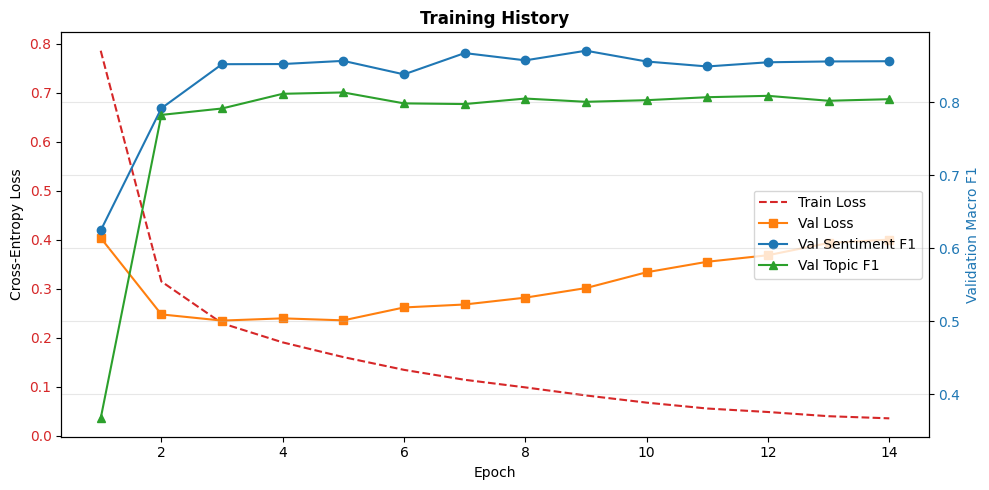


Chấn đoán trên validation === PhoBERT_HardSharing_Tuned ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9524    0.9660    0.9592       705
     Neutral     0.7344    0.6438    0.6861        73
    Positive     0.9677    0.9665    0.9671       805

    accuracy                         0.9514      1583
   macro avg     0.8848    0.8588    0.8708      1583
weighted avg     0.9501    0.9514    0.9506      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9409    0.9409    0.9409      1151
    Training     0.7322    0.8090    0.7687       267
    Facility     0.9538    0.8857    0.9185        70
      Others     0.6667    0.5053    0.5749        95

    accuracy                         0.8901      1583
   macro avg     0.8234    0.7852    0.8007      1583
weighted avg     0.8898    0.8901    0.8889      1583


=== (Test Cũ): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative 

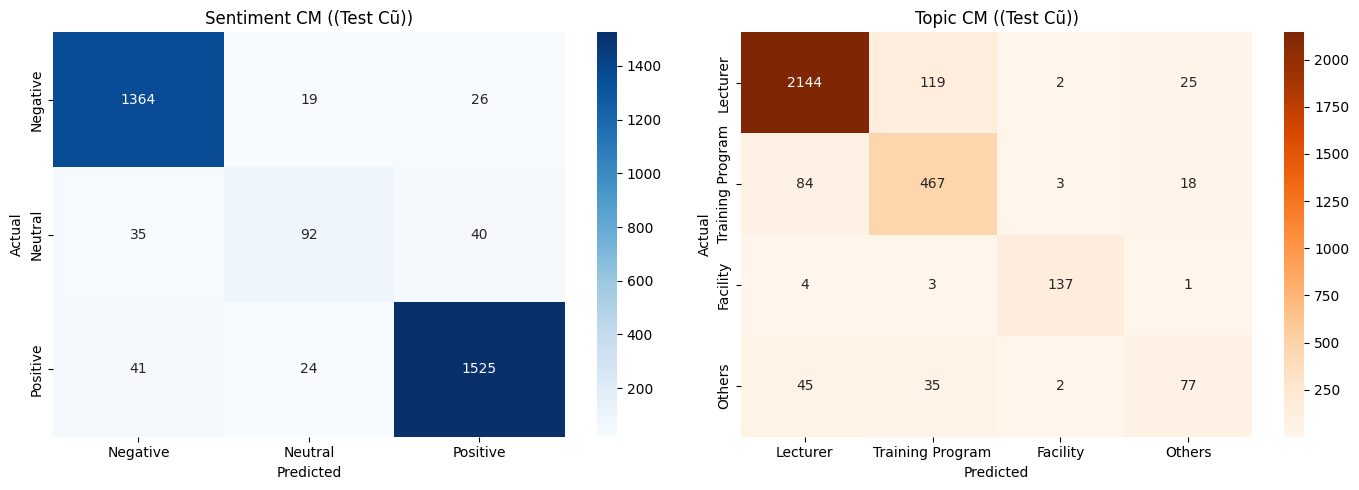


=== (Test Relabeled): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9563    0.9822    0.9690      1402
     Neutral     0.7333    0.6266    0.6758       158
    Positive     0.9811    0.9720    0.9765      1606

    accuracy                         0.9593      3166
   macro avg     0.8902    0.8602    0.8738      3166
weighted avg     0.9578    0.9593    0.9582      3166


=== (Test Relabeled): TOPIC REPORT ===
                  precision    recall  f1-score   support

        Lecturer     0.9627    0.9560    0.9593      2293
Training Program     0.8333    0.8799    0.8560       591
        Facility     0.9722    0.9589    0.9655       146
          Others     0.7190    0.6397    0.6770       136

        accuracy                         0.9283      3166
       macro avg     0.8718    0.8586    0.8645      3166
    weighted avg     0.9285    0.9283    0.9282      3166



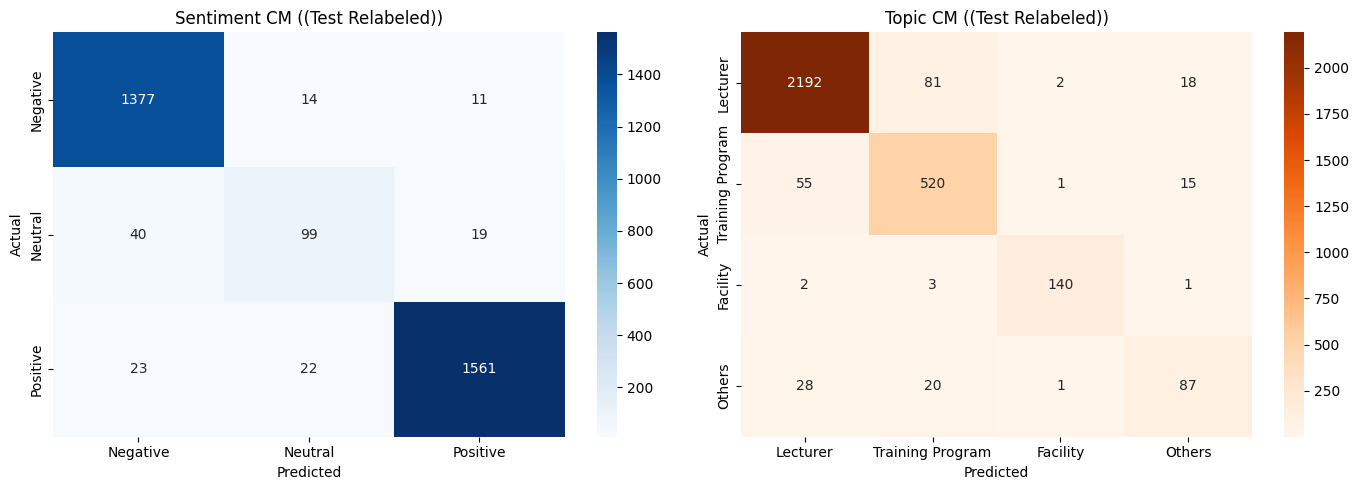


ABLATION STUDY — KẾT QUẢ TRÊN TẬP TEST CŨ (OLD TEST SET)
             Avg Macro F1  Sent macro-F1  S-Negative  S-Neutral*  S-Positive  Topic macro-F1  T-Lecturer  T-Training  T-Facility*  T-Others*
Model                                                                                                                                       
HS_CE_Tuned        0.8232         0.8419      0.9575      0.6093      0.9588          0.8045      0.9389      0.7809       0.9481     0.5500

ABLATION STUDY — KẾT QUẢ TRÊN TẬP TEST ĐÃ SỬA NHÃN (RELABELED TEST SET)
             Avg Macro F1  Sent macro-F1  S-Negative  S-Neutral*  S-Positive  Topic macro-F1  T-Lecturer  T-Training  T-Facility*  T-Others*
Model                                                                                                                                       
HS_CE_Tuned        0.8691         0.8738      0.9690      0.6758      0.9765          0.8645      0.9593      0.8560       0.9655     0.6770

(*) Ghi chú: Các lớp c

In [ ]:
# Lấy siêu tham số động từ đối tượng `study` của Optuna
best_lr_encoder = study.best_params["lr_encoder"]
best_lr_head = study.best_params["lr_head"]
best_dropout = study.best_params["dropout"]
best_weight_decay = study.best_params["weight_decay"]

print("\n" + "="*70)
print("MTL Hard Sharing + CE + Optuna Tuned")
print(f"Sử dụng tham số: LR_Enc={best_lr_encoder:.2e} | LR_Head={best_lr_head:.2e} | Drop={best_dropout} | WD={best_weight_decay:.3f}")
print("="*70)

# Khởi tạo mô hình với Dropout tối ưu
model_final_tuned = MTLHardSharing(dropout=best_dropout).to(DEVICE)

# GỌI HÀM TRAIN FINAL VỚI THAM SỐ TỐI ƯU VỪA TÌM ĐƯỢC
model_final_tuned, hist_final, val_f1_final = train_mtl_final(
    model=model_final_tuned, 
    train_loader=train_loader,   
    val_loader=val_loader,       
    loss_sent_fn=ce_sent,        
    loss_topic_fn=ce_topic,      
    lr_encoder=best_lr_encoder, 
    lr_head=best_lr_head, 
    weight_decay=best_weight_decay,
    lambda_s=0.6, 
    lambda_t=0.4, 
    accum_steps=ACCUM_STEPS,
    patience=5,
    model_name="PhoBERT_HardSharing_Tuned"
)

plot_mtl_history(hist_final, title="Training History")
diagnose_validation(model_final_tuned, val_loader, "PhoBERT_HardSharing_Tuned")

results_old_test["HS_CE_Tuned"] = evaluate_and_plot_mtl(
    model_final_tuned, test_loader, title_prefix="(Test Cũ)"
)
results_new_test["HS_CE_Tuned"] = evaluate_and_plot_mtl(
    model_final_tuned, test_loader1, title_prefix="(Test Relabeled)"
)

# ════════════════════════════════════════════════════════
# 6. IN BẢNG SO SÁNH KẾT QUẢ CHO CẢ 2 TEST SET
# ════════════════════════════════════════════════════════
def extract_per_class_f1(report, classes):
    return {c: round(report[c]["f1-score"], 4) for c in classes}

def generate_result_dataframe(results_dict):
    rows = []
    for name, res in results_dict.items():
        s_per = extract_per_class_f1(res["sent_report"], ["Negative","Neutral","Positive"])
        t_per = extract_per_class_f1(res["topic_report"], ["Lecturer","Training Program","Facility","Others"])
        rows.append({
            "Model":            name,
            "Avg Macro F1":     round((res["sent_macro_f1"] + res["topic_macro_f1"])/2, 4),
            "Sent macro-F1":    round(res["sent_macro_f1"], 4),
            "S-Negative":       s_per["Negative"],
            "S-Neutral*":       s_per["Neutral"],      
            "S-Positive":       s_per["Positive"],
            "Topic macro-F1":   round(res["topic_macro_f1"], 4),
            "T-Lecturer":       t_per["Lecturer"],
            "T-Training":       t_per["Training Program"],
            "T-Facility*":      t_per["Facility"],     
            "T-Others*":        t_per["Others"],       
        })
    return pd.DataFrame(rows).set_index("Model")

df_results_old = generate_result_dataframe(results_old_test)
df_results_new = generate_result_dataframe(results_new_test)

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 150)

print("\n" + "=" * 110)
print("ABLATION STUDY — KẾT QUẢ TRÊN TẬP TEST CŨ (OLD TEST SET)")
print("=" * 110)
print(df_results_old.to_string())

print("\n" + "=" * 110)
print("ABLATION STUDY — KẾT QUẢ TRÊN TẬP TEST ĐÃ SỬA NHÃN (RELABELED TEST SET)")
print("=" * 110)
print(df_results_new.to_string())
print("\n(*) Ghi chú: Các lớp có dấu * là lớp thiểu số mất cân bằng dữ liệu.")